# ЛЗ 6. Вероятностный прогноз сроков SaparTravel

## Важное ограничение источника
Файл `data/throughput.csv` содержит учебный ряд из 26 недель, приведённый в примере задания. Это **не** выгрузка закрытых issues SaparTravel и не фактический результат команды. Собственная история проекта пока слишком короткая (около двух недель), чтобы считать её надёжной выборкой. Перед защитой учебный CSV следует заменить данными преподавателя или воспроизводимой выгрузкой GitHub Issues и записать источник/период. Нулевые недели сохранены.

Прогнозируемый объём здесь — 15 историй MVP ST-01–ST-15 из Story Map. Сегодня для расчёта принято 9 октября 2026 года. Все даты ниже являются учебным сценарием, а не обещанием заказчику.

In [1]:
from datetime import date, timedelta
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
RUNS = 10_000
BACKLOG = 15  # MVP: ST-01 ... ST-15
AS_OF = date(2026, 10, 9)

candidates = [Path.cwd() / 'data' / 'throughput.csv', Path.cwd().parent / 'data' / 'throughput.csv']
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Не найден data/throughput.csv; запустите notebook из корня проекта или папки notebooks.')

df = pd.read_csv(data_path)
required_columns = {'week_index', 'throughput'}
if not required_columns.issubset(df.columns):
    raise ValueError(f'В CSV нужны колонки {sorted(required_columns)}')
if df['throughput'].isna().any() or (df['throughput'] < 0).any():
    raise ValueError('Throughput должен содержать только неотрицательные числа без пропусков.')
history = df['throughput'].astype(int).to_numpy()
if len(history) == 0 or not np.any(history > 0):
    raise ValueError('В истории должна быть хотя бы одна неделя с завершёнными элементами.')

print(f'Источник: {data_path.resolve()}')
print(f'Недель: {len(history)}; нулевых недель: {(history == 0).sum()}')
display(df.head(10))
display(pd.DataFrame({'показатель': ['Среднее', 'Медиана', 'Минимум', 'Максимум'], 'элементов в неделю': [history.mean(), np.median(history), history.min(), history.max()]}).round(2))

Источник: /home/akira/IdeaProjects/SaparTravel/data/throughput.csv
Недель: 26; нулевых недель: 2


,week_index,throughput
0,1,4
1,2,6
2,3,0
3,4,7
4,5,5
5,6,2
6,7,6
7,8,9
8,9,4
9,10,5


,показатель,элементов в неделю
0,Среднее,4.77
1,Медиана,5.00
2,Минимум,0.00
3,Максимум,9.00


В данных 26 недель, включая две недели с нулевым throughput. Их нельзя удалять: простой команды, сессия или болезнь влияют на календарный срок. Учебный ряд не содержит настоящих дат — `week_index` лишь сохраняет порядок наблюдений; это ограничение источника, а не пропуск, который можно заполнить догадкой.

In [2]:
rng = np.random.default_rng(SEED)
weeks_to_finish = np.empty(RUNS, dtype=int)

for run in range(RUNS):
    completed = 0
    weeks = 0
    while completed < BACKLOG:
        completed += int(rng.choice(history))
        weeks += 1
    weeks_to_finish[run] = weeks

PERCENTILES = (50, 70, 85, 95)
forecast = {}
for percentile in PERCENTILES:
    forecast[percentile] = int(np.percentile(weeks_to_finish, percentile, method='higher'))

forecast_table = pd.DataFrame([
    {'Уверенность': f'P{p}', 'Недель': weeks, 'Дата': AS_OF + timedelta(weeks=weeks)}
    for p, weeks in forecast.items()
])
display(forecast_table)
print(f'Среднее число недель в симуляциях: {weeks_to_finish.mean():.2f}')
print(f'Повторяемость: seed={SEED}, прогонов={RUNS:,}, backlog={BACKLOG}')

,Уверенность,Недель,Дата
0,P50,4,2026-11-06
1,P70,4,2026-11-06
2,P85,5,2026-11-13
3,P95,5,2026-11-13


Среднее число недель в симуляциях: 3.66
Повторяемость: seed=42, прогонов=10,000, backlog=15


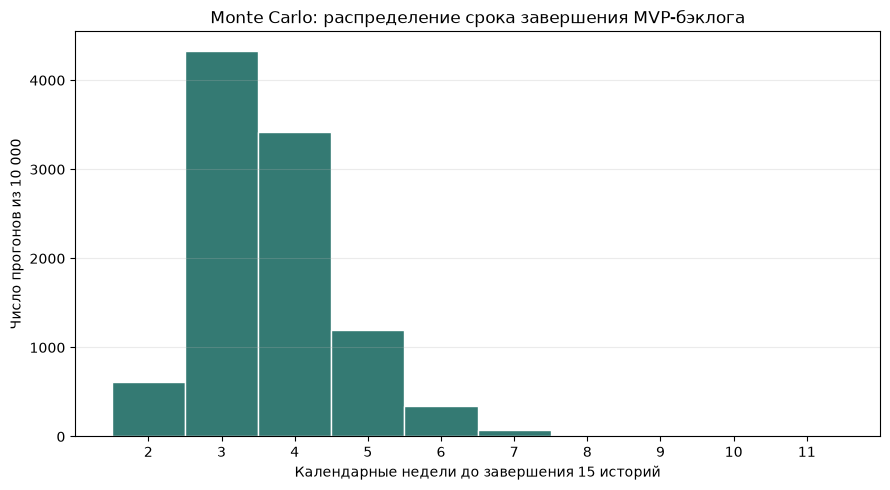

In [3]:
plt.figure(figsize=(9, 5))
bins = np.arange(weeks_to_finish.min(), weeks_to_finish.max() + 2) - 0.5
plt.hist(weeks_to_finish, bins=bins, color='#347a73', edgecolor='white')
plt.xlabel('Календарные недели до завершения 15 историй')
plt.ylabel('Число прогонов из 10 000')
plt.title('Monte Carlo: распределение срока завершения MVP-бэклога')
plt.xticks(np.arange(weeks_to_finish.min(), weeks_to_finish.max() + 1))
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

**Вывод по гистограмме.** Каждый столбец показывает, сколько из 10 000 случайных траекторий завершили backlog за соответствующее число недель. Это распределение возможных сроков при условии, что будущий throughput похож на учебную историю; оно не гарантирует конкретную дату. Нулевые недели увеличивают правый хвост.

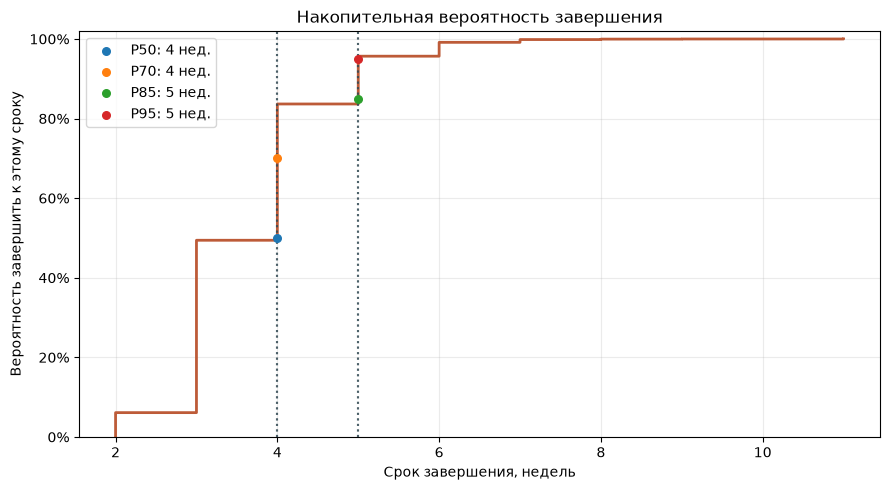

In [4]:
sorted_weeks = np.sort(weeks_to_finish)
cumulative_probability = np.arange(1, RUNS + 1) / RUNS
plt.figure(figsize=(9, 5))
plt.step(sorted_weeks, cumulative_probability, where='post', color='#bd5b38', linewidth=2)
for percentile, weeks in forecast.items():
    probability = percentile / 100
    plt.axvline(weeks, linestyle=':', alpha=0.65, color='#344b55')
    plt.scatter([weeks], [probability], s=30, zorder=3, label=f'P{percentile}: {weeks} нед.')
plt.xlabel('Срок завершения, недель')
plt.ylabel('Вероятность завершить к этому сроку')
plt.title('Накопительная вероятность завершения')
plt.ylim(0, 1.02)
plt.yticks(np.linspace(0, 1, 6), [f'{value:.0%}' for value in np.linspace(0, 1, 6)])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по накопительной кривой.** Для любой выбранной даты по оси X кривая показывает долю симуляций, в которых backlog завершён не позднее неё. Например, точка P85 означает: при принятых допущениях 85% прогонов завершились к указанному сроку, а в 15% случаев потребовалось больше времени. Для планирования с заказчиком разумно обсуждать пару уровней уверенности, а не одну дату.

In [5]:
# Учебное сопоставление с poker-протоколом; это не измеренная velocity команды.
POKERED_STORY_POINTS = 58  # ST-01 ... ST-10 из учебного протокола
REMAINING_STORY_POINTS = 17  # ST-11 ... ST-15: S=3, M=5 по условному mapping
BACKLOG_STORY_POINTS = POKERED_STORY_POINTS + REMAINING_STORY_POINTS
ASSUMED_VELOCITY_SP_PER_WEEK = 8
story_point_weeks = math.ceil(BACKLOG_STORY_POINTS / ASSUMED_VELOCITY_SP_PER_WEEK)
mean_throughput_weeks = BACKLOG / history.mean()
comparison = pd.DataFrame([
    {'Подход': 'Деление backlog на средний throughput', 'Расчётный срок, недель': f'{mean_throughput_weeks:.2f}', 'Статус': 'Ориентир по среднему, не уровень уверенности'},
    {'Подход': 'Story points / условная velocity (15 историй)', 'Расчётный срок, недель': f'{story_point_weeks} (округление вверх)', 'Статус': '75 SP / 8 SP в неделю; velocity пока допущение'},
    {'Подход': 'Monte Carlo P85', 'Расчётный срок, недель': str(forecast[85]), 'Статус': '85% учебных прогонов завершились не позднее срока'},
])
display(comparison)
print('Имеющийся 12-недельный план WBS включает 171 человеко-час и работы за пределами подсчёта 15 историй; единицы измерения и границы объёма отличаются.')

,Подход,"Расчётный срок, недель",Статус
0,Деление backlog на средний throughput,3.15,"Ориентир по среднему, не уровень уверенности"
1,Story points / условная velocity (15 историй),10 (округление вверх),75 SP / 8 SP в неделю; velocity пока допущение
2,Monte Carlo P85,5,85% учебных прогонов завершились не позднее срока


Имеющийся 12-недельный план WBS включает 171 человеко-час и работы за пределами подсчёта 15 историй; единицы измерения и границы объёма отличаются.


## Сопоставление и ограничения
Детерминированный ориентир `15 / средний throughput` использует среднее значение и даёт число недель, но не вероятность. Для сопоставления одного и того же backlog из 15 историй story-point сценарий складывает 58 SP из учебного poker-протокола для ST-01–ST-10 и 17 SP для ST-11–ST-15. Последние получены только условным переводом сохранённых T-shirt размеров: S=3, M=5. Итого 75 SP; деление на условные 8 SP/неделю даёт 10 недель. Команда ещё не измерила собственную velocity, поэтому это не фактический прогноз. Исторический ряд тоже учебный, а throughput считает элементы одинаковыми, хотя истории различаются по размеру.

Уже имеющийся WBS оценивает полный проект в 171 человеко-час на 12 недель, включая управление, проверку, миграцию, UAT и передачу. Его нельзя прямо приравнять к 15 историям или к story points. Расхождение чисел объясняется разными границами объёма и единицами, условной velocity, неодинаковым размером задач и тем, что деление на среднее не отвечает на вопрос о вероятности. Перед клиентским обязательством нужны фактический backlog, одна согласованная единица потока и достаточная история команды.

### Решение по плану
До проверки источника использовать результат только как сценарный диапазон. Уточнить источники throughput и критерии готовности историй, не добавлять новые задачи в текущий MVP без пересчёта, а на следующей контрольной дате обновить прогноз после получения свежей недели данных.